# How the Allen Visual Coding Neuropixels spreadsheet is measured

1. **What is in Allen VCN?** The two session types, the files, and what we kept.
2. **From that, how do we get the spreadsheet numbers?** Subjects, trials, neurons, length, sizes.
3. **Figures.** Neurons, firing rates, trials (by stimulus), trials × neurons, regions, raster.
4. **Which sessions the draft uses.**

The data lives on HAL (`~/ismael/allen/data`, 146.2 GB, everything in the public bucket except LFP).
`data/allen/allen_extract.py` reduced it there to the small tables in `data/allen/tables/` (22 MB), which this
notebook reads.

## 1. What is in Allen VCN

- **Visual Coding – Neuropixels** (Siegle et al. 2021): **58 sessions, 58 mice** (one session per mouse),
  up to 6 Neuropixels 1.0 probes per session through visual cortex, hippocampus and thalamus. Head-fixed,
  passive viewing, running on a wheel. Released on S3 as `s3://allen-brain-observatory/visual-coding-neuropixels/ecephys-cache/`.
- **Two session types, different stimulus sets:**
  - **Brain Observatory 1.1 (BO), 32 sessions.** Gabors, flashes, drifting gratings (8 directions × 5 temporal
    frequencies), static gratings, 118 natural scenes, natural movies one and three. 8 of the 32 sessions
    also show drifting gratings × contrast.
  - **Functional Connectivity (FC), 26 sessions.** Gabors, flashes, dot motion, drifting gratings at one TF
    with 75 repeats, drifting gratings × contrast, and natural movie one with more repeats plus a shuffled version.
    FC trades stimulus variety for more repeats.
- **Spike sorting:** Kilosort2. Each NWB holds every unit, including `quality == 'noise'` artifacts.
  AllenSDK's default unit QC (used here as **QC units**) is `quality == 'good'` & ISI violations < 0.5 &
  amplitude cutoff < 0.1 & presence ratio > 0.9.

**Allen terms, briefly**

- **Allen Brain Observatory vs Allen Brain Atlas.** The *Observatory* is the recording project this data comes
  from. The *Atlas* (Common Coordinate Framework, CCF v3) is the Allen Institute's 3D reference mouse brain;
  each probe's track is registered to it, and that is where the region labels (VISp, CA1, LGd, ...) come from.
  IBL uses the same atlas.
- **"Functional Connectivity" is only the name of a stimulus protocol.** It shows fewer stimulus types with many
  more repeats, which is what estimating correlations and interactions between simultaneously recorded neurons
  needs. It has nothing to do with fMRI functional connectivity, and no connectivity data is shipped. The
  recordings are the same kind as BO: Neuropixels spikes during passive viewing.
- **ISI violations / amplitude cutoff / presence ratio** — the three QC metrics. ISI violations estimates the
  fraction of spikes from other neurons (spikes closer than the refractory period); amplitude cutoff estimates the
  fraction of the unit's spikes missed because they fell below the detection threshold; presence ratio is the
  fraction of the session in which the unit fires at all (it catches units that drift away).
- **Opto-tagging** — the Cre;Ai32 mice express channelrhodopsin in one cell type; light pulses at the end of the
  session make those neurons fire, so they can be identified. Those pulses are not counted as trials.

**What the bucket holds, and what we kept** (sizes from the S3 listing):

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

here = Path.cwd().resolve()
REPO = here
for candidate in [here, *here.parents]:
    if (candidate / "src" / "ladys").is_dir() or (candidate / "data" / "allen" / "tables").exists():
        REPO = candidate
        break
TABLES = REPO / "data" / "allen" / "tables"
FIGURE_DIR = REPO / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
assert TABLES.exists(), f"Expected extracted tables at {TABLES}; see data/allen/README.md"
GB = 1e9
BO, FC = "brain_observatory_1.1", "functional_connectivity"
SHORT = {BO: "BO", FC: "FC"}
TYPE_COLOR = {BO: "C0", FC: "C1"}

sessions = pd.read_parquet(TABLES / "sessions.parquet")
units = pd.read_parquet(TABLES / "units.parquet")
stimuli = pd.read_parquet(TABLES / "stimuli.parquet")
bucket = pd.read_csv(TABLES / "bucket_files.csv")
storage = pd.read_csv(TABLES / "nwb_storage.csv")

session_type = sessions.set_index("session_id").session_type
units["type"] = units.session_id.map(session_type)
units["good"] = units.quality == "good"
stimuli["type"] = stimuli.session_id.map(session_type)
bucket["type"] = bucket.session_id.map(session_type)

files = {
    "session_nwb": ("session_<id>.nwb: spikes, units, stimulus tables, running, eye tracking", "kept"),
    "session_metrics": ("session_<id>_analysis_metrics.csv: per-unit tuning metrics", "kept"),
    "lfp": ("probe_<id>_lfp.nwb: 1250 Hz LFP per probe", "ditched"),
    "templates": ("natural scene images + natural movie frames", "kept"),
    "metadata": ("sessions / probes / channels / units CSVs, manifest", "kept"),
}
display(pd.DataFrame([
    {"files": k, "what": w, "count": int((bucket.kind == k).sum()),
     "GB": round(bucket.bytes[bucket.kind == k].sum() / GB, 2), "kept?": kept}
    for k, (w, kept) in files.items()
]))
print(f"whole bucket: {bucket.bytes.sum() / GB:,.2f} GB; kept: {bucket.bytes[bucket.kind != 'lfp'].sum() / GB:,.2f} GB")

,files,what,count,GB,kept?
0,session_nwb,"session_<id>.nwb: spikes, units, stimulus tables, running, eye tracking",58,144.97,kept
1,session_metrics,session_<id>_analysis_metrics.csv: per-unit tuning metrics,58,0.08,kept
2,lfp,probe_<id>_lfp.nwb: 1250 Hz LFP per probe,325,707.55,ditched
3,templates,natural scene images + natural movie frames,120,0.96,kept
4,metadata,"sessions / probes / channels / units CSVs, manifest",7,0.14,kept


whole bucket: 853.71 GB; kept: 146.15 GB


There is no raw 30 kHz voltage in the bucket; spikes are the rawest public form besides LFP.

**Inside the session NWBs** (HDF5 storage, summed over the 58 files): more than half is per-spike amplitudes and
mean waveforms, neither of which a spiking benchmark needs.

In [2]:
nwb = storage.drop(columns="session_id").sum() / GB
display(nwb.round(2).rename("GB").to_frame().T)

,spike_times,spike_amplitudes,waveform_mean,other
GB,51.17,51.17,34.4,7.44


In [3]:
checks = {
    "sessions": (len(sessions), 58),
    "BO sessions": (int((sessions.session_type == BO).sum()), 32),
    "FC sessions": (int((sessions.session_type == FC).sum()), 26),
    "mice": (sessions.specimen_id.nunique(), 58),
    "QC units (AllenSDK default)": (int(units.qc.sum()), 41_552),
}
display(pd.DataFrame(checks, index=["measured", "expected"]).T)
for name, (measured, expected) in checks.items():
    assert measured == expected, name
assert sessions.units.sum() == len(units)
print(f"units in NWBs: {len(units):,} ({units.good.sum():,} good, {(~units.good).sum():,} noise)")
print("(the cache's units.csv lists 135,275, 99,180 good; the NWBs hold 1,281 more, and the NWBs are what is counted)")

,measured,expected
sessions,58,58
BO sessions,32,32
FC sessions,26,26
mice,58,58
QC units (AllenSDK default),41552,41552


units in NWBs: 136,556 (99,844 good, 36,712 noise)
(the cache's units.csv lists 135,275, 99,180 good; the NWBs hold 1,281 more, and the NWBs are what is counted)


## 2. How those files become spreadsheet numbers

One row per session type, because BO and FC show different stimuli.

- **SUBJECTS**: mice (`specimen_id`). One session per mouse.
- **TRIALS**: stimulus presentations, i.e. rows of the NWB `*_presentations` tables. Natural movies are
  counted per repeat (a 30 s movie is one trial, not 900 frames). Spontaneous blocks are not trials.
  One BO gabor, static grating or natural scene lasts 250 ms, so these dominate the count.
- **NEURONS**: QC units (AllenSDK default filter). The draft's Allen splits appear to use a subset of these (section 4).
  TOTAL = sum and MEDIAN = per session, rounded half up (all probes of a session are simultaneous). All and good counts go in NOTES.
- **CHANNELS**: `N/A` (sorted units).
- **LENGTH**: per session, first to last spike, summed over sessions.
- **RAW**: everything the bucket holds for these sessions: session NWBs, per-probe LFP NWBs and unit metric CSVs.
- **BENCHMARK**: a QC-units build. It keeps spike times of QC units only (8 bytes per spike, as stored) plus
  the NWB's non-spike datasets (stimulus tables, unit metadata, running, eye tracking) and the metric CSVs.
  It also keeps the stimulus templates the type shows. Per-spike amplitudes and mean waveforms are dropped.
  Natural movie one (0.17 GB) is shown in both types and is counted in both rows. Shared metadata CSVs
  (0.14 GB) are left out.
- **BASIC STATS**: one firing rate per QC unit, from the NWB `firing_rate` column (whole-session rate).

Per-session table:

In [4]:
trial_stims = stimuli[stimuli.stimulus != "spontaneous"]
sessions["trials"] = sessions.session_id.map(trial_stims.groupby("session_id").size())
sessions["recording_min"] = sessions.recording_s / 60
sessions["stimulus_min"] = sessions.stimulus_s / 60
sessions = sessions.sort_values(["session_type", "trials", "units"], ignore_index=True)
cols = ["probes", "units", "good_units", "qc_units", "trials", "recording_min", "stimulus_min", "age_days"]
display(sessions.groupby("session_type")[cols].agg(["min", "median", "max"]).T.unstack(0).round(1))
display(sessions.genotype.value_counts().rename("sessions").to_frame())

session_type brain_observatory_1.1                                                                          functional_connectivity                     \
                            probes   units good_units qc_units   trials recording_min stimulus_min age_days                  probes   units good_units   
min                            4.0  1603.0     1191.0    452.0  16403.0         154.5        152.0     91.0                     5.0  1478.0     1079.0   
median                         6.0  2292.0     1683.5    681.5  16405.0         161.4        152.1    110.0                     6.0  2495.5     1823.0   
max                            6.0  3232.0     2816.0    984.0  16945.0         178.0        161.6    141.0                     6.0  3071.0     2261.0   

session_type                                                       
             qc_units  trials recording_min stimulus_min age_days  
min             429.0  5435.0         160.4        152.1    108.0  
median          736.0  5435.0         164.0        152.1    121.5  
max            1036.0  5510.0         178.5        154.6    142.0

,sessions
genotype,
wt/wt,30
Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,12
Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,8
Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,8


## 3. Figures

### Stimuli: what the mouse sees

Every session opens with gabors and flashes, then plays one of two fixed programs, BO or FC. One tile per
stimulus: what changes from trial to trial, trial length and repeats, and what the stimulus probes (→). Photos
and movie frames are the real stimuli (`TABLES / "stim_samples"`: 4 of the 118 natural scenes and 6 frames of
natural movie one, see `data/allen/README.md`); gratings, patches, flashes and dots are drawn from the stimulus
parameters (schematic, not to scale). Conditions and durations come from `stimuli` and the technical whitepaper
(pp. 17–18).

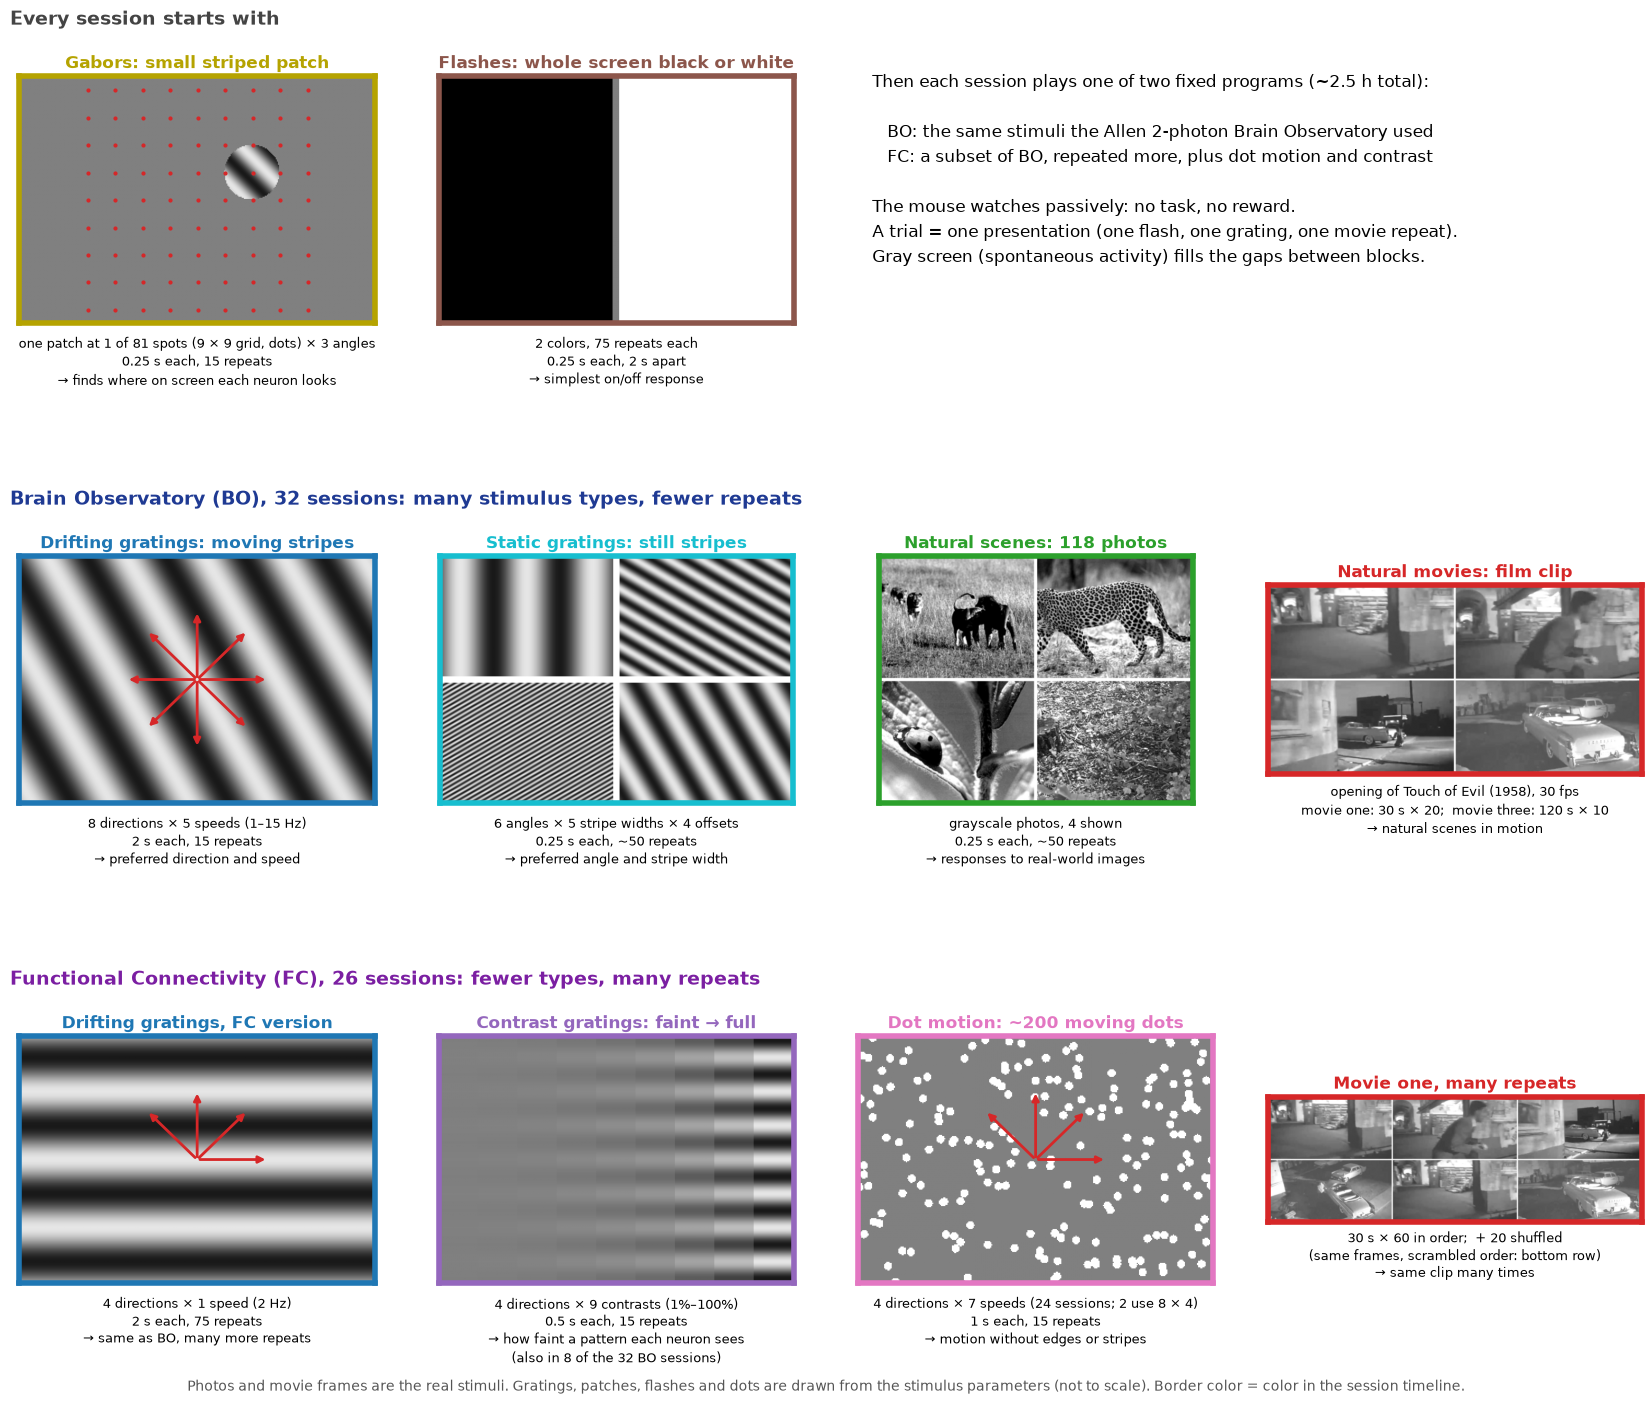

In [5]:
from PIL import Image

SAMPLES = TABLES / "stim_samples"
STIM_COLOR = {
    "gabors": "#b5a300", "flashes": "#8c564b", "drifting_gratings": "#1f77b4", "static_gratings": "#17becf",
    "natural_scenes": "#2ca02c", "natural_movie_one": "#d62728", "natural_movie_three": "#ff7f0e",
    "drifting_gratings_contrast": "#9467bd", "dot_motion": "#e377c2", "natural_movie_one_shuffled": "#f4a6a6",
    "spontaneous": "#d9d9d9",
}
# FC variants of a BO stimulus share its color
STIM_COLOR["drifting_gratings_75_repeats"] = STIM_COLOR["drifting_gratings"]
STIM_COLOR["natural_movie_one_more_repeats"] = STIM_COLOR["natural_movie_one"]

# Schematic screen: 130 x 90 degrees of visual angle at 2.5 px/deg
W, H = 325, 225
SX, SY = np.meshgrid(np.linspace(-65, 65, W), np.linspace(45, -45, H))


def grating(ori_deg, sf=0.04, contrast=0.8, phase=0.0):
    t = np.deg2rad(ori_deg)
    return 0.5 + 0.5 * contrast * np.cos(2 * np.pi * sf * (SX * np.cos(t) + SY * np.sin(t)) + phase)


def mosaic(images, ncols, pad=6):
    h, w = images[0].shape
    nrows = int(np.ceil(len(images) / ncols))
    out = np.ones((nrows * h + (nrows - 1) * pad, ncols * w + (ncols - 1) * pad))
    for i, im in enumerate(images):
        r, c = divmod(i, ncols)
        out[r * (h + pad): r * (h + pad) + h, c * (w + pad): c * (w + pad) + w] = im
    return out


def direction_arrows(ax, angles):
    for a in np.deg2rad(angles):
        ax.annotate("", xy=(0.5 + 0.2 * np.cos(a), 0.5 + 0.28 * np.sin(a)), xytext=(0.5, 0.5),
                    xycoords="axes fraction", arrowprops=dict(arrowstyle="-|>", color="C3", lw=2))


def stim_tile(ax, img, key, title, lines):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="bilinear")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color(STIM_COLOR[key])
        s.set_linewidth(4)
    ax.set_title(title, fontsize=12, fontweight="bold", color=STIM_COLOR[key], pad=6)
    ax.text(0.5, -0.05, "\n".join(lines), transform=ax.transAxes, ha="center", va="top", fontsize=9.5,
            linespacing=1.35)


gabor = np.full((H, W), 0.5)
patch = (SX - 20) ** 2 + (SY - 10) ** 2 < 10 ** 2  # 20 deg circular mask
gabor[patch] = grating(45, sf=0.08)[patch]
flash = np.zeros((H, W))
flash[:, W // 2:] = 1
flash[:, W // 2 - 3: W // 2 + 3] = 0.5
dots = np.full((H, W), 0.5)
rng = np.random.default_rng(0)
for x, y in zip(rng.uniform(-65, 65, 200), rng.uniform(-45, 45, 200)):
    dots[(SX - x) ** 2 + (SY - y) ** 2 < 1.5 ** 2] = 1.0
contrasts = np.array([0.01, 0.02, 0.04, 0.08, 0.13, 0.2, 0.35, 0.6, 1.0])
strip = np.minimum(((SX + 65) / 130 * len(contrasts)).astype(int), len(contrasts) - 1)
contrast_steps = 0.5 + (grating(90, sf=0.08) - 0.5) * contrasts[strip]
static = mosaic([grating(o, sf=f, phase=p)[::2, ::2] for o, f, p in [(0, 0.02, 0), (60, 0.08, 1), (120, 0.32, 2),
                                                                   (30, 0.04, 3)]], 2)
scenes = [np.asarray(Image.open(SAMPLES / f"natural_scene_{i}.tiff").convert("L").resize((294, 230))) / 255
          for i in (5, 17, 42, 88)]
frames = np.load(SAMPLES / "natural_movie_one_frames.npy") / 255  # movie one frames 0, 150, ..., 750

fig = plt.figure(figsize=(17, 14.8))
gs = fig.add_gridspec(3, 4, hspace=0.95, wspace=0.12, left=0.02, right=0.98, top=0.9, bottom=0.085)
tiles = [
    (0, 0, gabor, "gabors", "Gabors: small striped patch",
     ["one patch at 1 of 81 spots (9 × 9 grid, dots) × 3 angles", "0.25 s each, 15 repeats",
      "→ finds where on screen each neuron looks"], None),
    (0, 1, flash, "flashes", "Flashes: whole screen black or white",
     ["2 colors, 75 repeats each", "0.25 s each, 2 s apart", "→ simplest on/off response"], None),
    (1, 0, grating(30), "drifting_gratings", "Drifting gratings: moving stripes",
     ["8 directions × 5 speeds (1–15 Hz)", "2 s each, 15 repeats", "→ preferred direction and speed"],
     range(0, 360, 45)),
    (1, 1, static, "static_gratings", "Static gratings: still stripes",
     ["6 angles × 5 stripe widths × 4 offsets", "0.25 s each, ~50 repeats", "→ preferred angle and stripe width"],
     None),
    (1, 2, mosaic(scenes, 2), "natural_scenes", "Natural scenes: 118 photos",
     ["grayscale photos, 4 shown", "0.25 s each, ~50 repeats", "→ responses to real-world images"], None),
    (1, 3, mosaic(list(frames[:4]), 2), "natural_movie_one", "Natural movies: film clip",
     ["opening of Touch of Evil (1958), 30 fps", "movie one: 30 s × 20;  movie three: 120 s × 10",
      "→ natural scenes in motion"], None),
    (2, 0, grating(90), "drifting_gratings_75_repeats", "Drifting gratings, FC version",
     ["4 directions × 1 speed (2 Hz)", "2 s each, 75 repeats", "→ same as BO, many more repeats"], [0, 45, 90, 135]),
    (2, 1, contrast_steps, "drifting_gratings_contrast", "Contrast gratings: faint → full",
     ["4 directions × 9 contrasts (1%–100%)", "0.5 s each, 15 repeats", "→ how faint a pattern each neuron sees",
      "(also in 8 of the 32 BO sessions)"], None),
    (2, 2, dots, "dot_motion", "Dot motion: ~200 moving dots",
     ["4 directions × 7 speeds (24 sessions; 2 use 8 × 4)", "1 s each, 15 repeats",
      "→ motion without edges or stripes"], [0, 45, 90, 135]),
    (2, 3, mosaic([frames[i] for i in (0, 1, 2, 4, 0, 3)], 3), "natural_movie_one_more_repeats",
     "Movie one, many repeats",
     ["30 s × 60 in order;  + 20 shuffled", "(same frames, scrambled order: bottom row)", "→ same clip many times"],
     None),
]
for r, c, img, key, title, lines, angles in tiles:
    ax = fig.add_subplot(gs[r, c])
    stim_tile(ax, img, key, title, lines)
    if angles is not None:
        direction_arrows(ax, angles)
    if key == "gabors":
        gx, gy = np.meshgrid(np.arange(-40, 41, 10), np.arange(-40, 41, 10))
        ax.scatter((gx.ravel() + 65) * 2.5, (45 - gy.ravel()) * 2.5, s=4, c="C3")
        ax.set(xlim=(0, W - 1), ylim=(H - 1, 0))

ax = fig.add_subplot(gs[0, 2:])
ax.axis("off")
ax.text(0.03, 0.62,
        "Then each session plays one of two fixed programs (~2.5 h total):\n\n"
        "   BO: the same stimuli the Allen 2-photon Brain Observatory used\n"
        "   FC: a subset of BO, repeated more, plus dot motion and contrast\n\n"
        "The mouse watches passively: no task, no reward.\n"
        "A trial = one presentation (one flash, one grating, one movie repeat).\n"
        "Gray screen (spontaneous activity) fills the gaps between blocks.",
        fontsize=12, va="center", linespacing=1.5)

rows = [("Every session starts with", "#444444"),
        (f"Brain Observatory (BO), {(sessions.session_type == BO).sum()} sessions: many stimulus types, fewer repeats",
         "#1f3a93"),
        (f"Functional Connectivity (FC), {(sessions.session_type == FC).sum()} sessions: fewer types, many repeats",
         "#7b1fa2")]
for r, (label, color) in enumerate(rows):
    top = max(a.get_position().y1 for a in fig.axes if a.get_subplotspec().rowspan.start == r and a.images)
    fig.text(0.02, top + 0.035, label, fontsize=14, fontweight="bold", color=color)
fig.text(0.5, 0.012, "Photos and movie frames are the real stimuli. Gratings, patches, flashes and dots are drawn "
         "from the stimulus parameters (not to scale). Border color = color in the session timeline.",
         ha="center", fontsize=10, color="#555555")
fig.savefig(FIGURE_DIR / "allen_stimuli.png", dpi=150)
plt.show()

### Session timeline

One BO and one FC session from start to end, colored as in the gallery (gray = gray screen, spontaneous
activity). Both share the first ~26 min; BO then cycles through many stimuli in short blocks, FC repeats a few.
The FC example is a typical one (24 of 26 FC sessions show 4 dot directions).

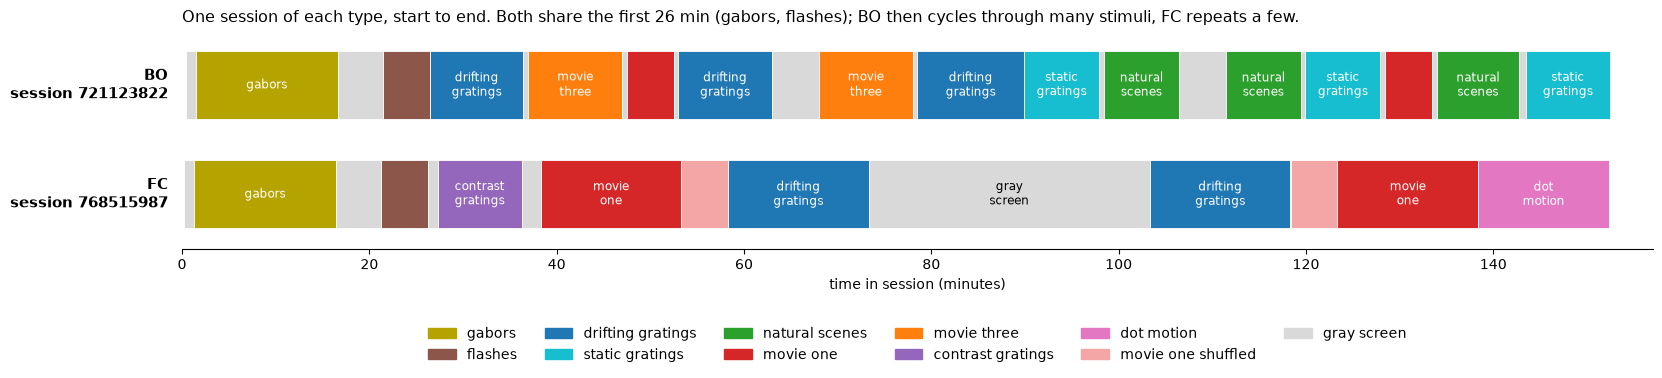

In [6]:
STIM_NAME = {
    "gabors": "gabors", "flashes": "flashes", "drifting_gratings": "drifting gratings",
    "drifting_gratings_75_repeats": "drifting gratings", "static_gratings": "static gratings",
    "natural_scenes": "natural scenes", "natural_movie_one": "movie one", "natural_movie_one_more_repeats": "movie one",
    "natural_movie_three": "movie three", "natural_movie_one_shuffled": "movie one shuffled",
    "drifting_gratings_contrast": "contrast gratings", "dot_motion": "dot motion", "spontaneous": "gray screen",
}


def stimulus_blocks(session_id):
    """Consecutive presentations of the same stimulus merged into one block, in minutes."""
    x = stimuli[stimuli.session_id == session_id].sort_values("start_time")
    run = (x.stimulus != x.stimulus.shift()).cumsum()
    b = x.groupby(run).agg(stim=("stimulus", "first"), t0=("start_time", "min"), t1=("stop_time", "max"))
    return b.assign(t0=b.t0 / 60, t1=b.t1 / 60)


bo = sessions[sessions.session_type == BO].session_id.iloc[0]
dot_dirs = stimuli[stimuli.stimulus == "dot_motion"].groupby("session_id").Dir.nunique()
fc = dot_dirs[dot_dirs == 4].index[0]

fig, ax = plt.subplots(figsize=(17, 4.2))
for y, (label, sid) in zip((1, 0), [("BO", bo), ("FC", fc)]):
    for b in stimulus_blocks(sid).itertuples():
        ax.barh(y, b.t1 - b.t0, left=b.t0, height=0.62, color=STIM_COLOR[b.stim], edgecolor="white", lw=0.6)
        if b.t1 - b.t0 >= 7.5:
            name = STIM_NAME[b.stim].replace(" ", "\n")
            dark = b.stim not in ("spontaneous", "natural_movie_one_shuffled")
            ax.text((b.t0 + b.t1) / 2, y, name, ha="center", va="center", fontsize=8.5, color="w" if dark else "k")
    ax.text(-1.5, y, f"{label}\nsession {sid}", ha="right", va="center", fontsize=11, fontweight="bold")
ax.set(xlim=(0, 157), ylim=(-0.5, 1.5), yticks=[], xlabel="time in session (minutes)")
for s in ("left", "right", "top"):
    ax.spines[s].set_visible(False)
shown = ["gabors", "flashes", "drifting_gratings", "static_gratings", "natural_scenes", "natural_movie_one",
         "natural_movie_three", "drifting_gratings_contrast", "dot_motion", "natural_movie_one_shuffled",
         "spontaneous"]
ax.legend([plt.Rectangle((0, 0), 1, 1, color=STIM_COLOR[k]) for k in shown], [STIM_NAME[k] for k in shown],
          loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=6, frameon=False, fontsize=10)
ax.set_title("One session of each type, start to end. Both share the first 26 min (gabors, flashes); BO then "
             "cycles through many stimuli, FC repeats a few.", fontsize=11.5, loc="left")
fig.subplots_adjust(left=0.125, right=0.99, top=0.88, bottom=0.36)
fig.savefig(FIGURE_DIR / "allen_session_timeline.png", dpi=150)
plt.show()

### Neurons per session

One histogram per unit set: all units, good units (not noise) and QC units per session. Within a panel the
bars are stacked by session type. Every session has QC ≤ good ≤ all, so each histogram sits left of the
previous one.

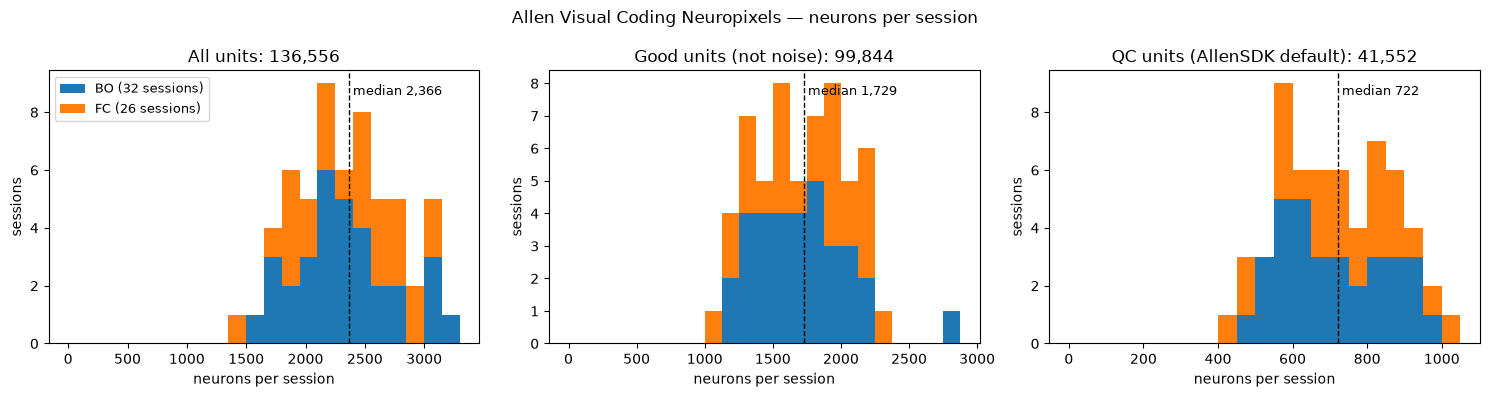

In [7]:
def half_up(x):
    return int(np.floor(x + 0.5))


def median_line(ax, values, color="k"):
    m = float(np.median(values))
    ax.axvline(m, color=color, ls="--", lw=1)
    ax.text(m, ax.get_ylim()[1] * 0.95, f" median {half_up(m):,}", color=color, va="top", fontsize=9)


assert (sessions.qc_units <= sessions.good_units).all() and (sessions.good_units <= sessions.units).all()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, bins in [
    (axes[0], "units", "All units", np.arange(0, 3400, 150)),
    (axes[1], "good_units", "Good units (not noise)", np.arange(0, 3000, 125)),
    (axes[2], "qc_units", "QC units (AllenSDK default)", np.arange(0, 1100, 50)),
]:
    groups = [sessions.loc[sessions.session_type == t, col] for t in (BO, FC)]
    ax.hist(groups, bins=bins, stacked=True, color=[TYPE_COLOR[BO], TYPE_COLOR[FC]],
            label=[f"{SHORT[t]} ({len(g)} sessions)" for t, g in zip((BO, FC), groups)])
    ax.set(title=f"{title}: {sessions[col].sum():,}", xlabel="neurons per session", ylabel="sessions")
    median_line(ax, sessions[col])
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle("Allen Visual Coding Neuropixels — neurons per session")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_neurons_per_session.png", dpi=150)
plt.show()

### Firing rates

One rate per unit (NWB `firing_rate`, spikes over the whole session). Outline = good (Kilosort2 not noise),
blue = AllenSDK QC. QC is a subset of good, so blue always sits inside the outline. The QC presence-ratio cut
removes most of the very low-rate units. All units (including noise) are left out of the plot; their rates are
in the table below.

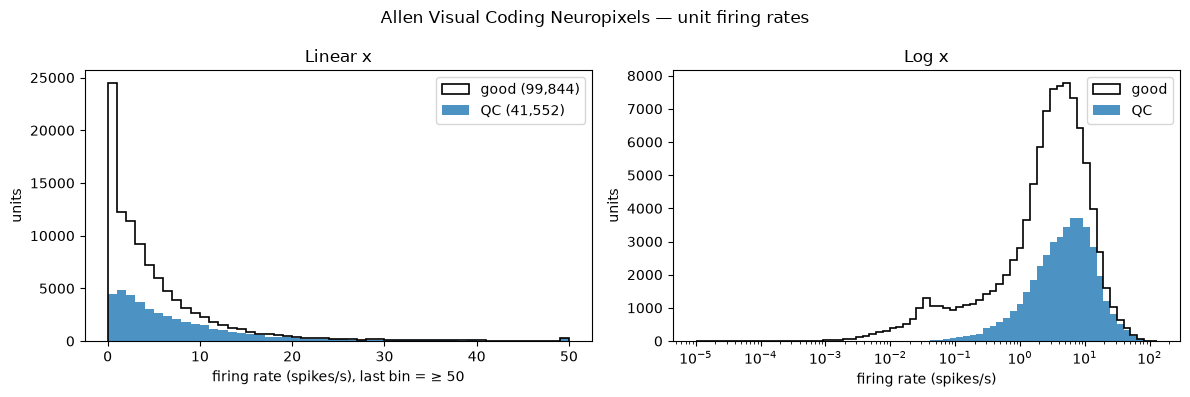

,units,mean Hz,median Hz
all all,136556.0,4.79,2.77
all BO,74658.0,4.93,2.93
all FC,61898.0,4.62,2.58
good all,99844.0,5.29,3.17
good BO,54476.0,5.46,3.39
good FC,45368.0,5.08,2.94
QC all,41552.0,7.72,5.15
QC BO,22638.0,7.93,5.52
QC FC,18914.0,7.47,4.76


In [8]:
fr = units.firing_rate
good, qc = fr[units.good], fr[units.qc]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
bins = np.arange(0, 51, 1)
ax.hist(good.clip(upper=50), bins=bins, histtype="step", color="k", lw=1.2, label=f"good ({len(good):,})")
ax.hist(qc.clip(upper=50), bins=bins, color="C0", alpha=0.8, label=f"QC ({len(qc):,})")
ax.set(xlabel="firing rate (spikes/s), last bin = ≥ 50", ylabel="units", title="Linear x")
ax.legend()
ax = axes[1]
pos = good[good > 0]
bins = np.logspace(np.floor(np.log10(pos.min())), np.log10(pos.max()) + 0.05, 70)
ax.hist(pos, bins=bins, histtype="step", color="k", lw=1.2, label="good")
ax.hist(qc[qc > 0], bins=bins, color="C0", alpha=0.8, label="QC")
ax.set_xscale("log")
ax.set(xlabel="firing rate (spikes/s)", ylabel="units", title="Log x")
ax.legend()
fig.suptitle("Allen Visual Coding Neuropixels — unit firing rates")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_firing_rates.png", dpi=150)
plt.show()

display(pd.DataFrame({
    f"{name} {SHORT.get(t, 'all')}": {"units": int(m.sum()), "mean Hz": fr[m].mean(), "median Hz": fr[m].median()}
    for name, mask in [("all", fr.notna()), ("good", units.good), ("QC", units.qc)]
    for t, m in [("all", mask), (BO, mask & (units.type == BO)), (FC, mask & (units.type == FC))]
}).T.round(2))

### Trials by stimulus

Every session of a type runs the same fixed protocol (the only variation: 8 of the 32 BO sessions add a
drifting-gratings-contrast block, and a few sessions lose some presentations). So which stimuli a session
has, and how many, is set by its type, and a table says it better than a per-session plot.

- **trials / session** — median [min – max] presentations per session (movies counted per repeat).
- **trial length** — median duration of one presentation.
- **min / session** — stimulus time per session. The 250 ms stimuli dominate the trial counts but not the time.

In [9]:
STIM_ORDER = ["flashes", "drifting_gratings", "drifting_gratings_contrast", "drifting_gratings_75_repeats",
              "static_gratings", "gabors", "dot_motion", "natural_scenes", "natural_movie_one",
              "natural_movie_one_more_repeats", "natural_movie_one_shuffled", "natural_movie_three", "spontaneous"]
STIM_WHAT = {
    "flashes": "whole screen turns white or black",
    "drifting_gratings": "moving black-white stripes; 8 directions × 5 temporal frequencies",
    "drifting_gratings_contrast": "moving stripes at several contrasts",
    "drifting_gratings_75_repeats": "moving stripes, 4 directions at one temporal frequency, many repeats",
    "static_gratings": "still stripes; several orientations × spatial frequencies × phases",
    "gabors": "small striped patch at one of a grid of screen positions (maps receptive fields)",
    "dot_motion": "field of moving dots; several directions and speeds",
    "natural_scenes": "118 still photographs",
    "natural_movie_one": "30 s black-and-white film clip (one trial = one full playthrough)",
    "natural_movie_one_more_repeats": "the same 30 s clip, more repeats",
    "natural_movie_one_shuffled": "the same clip with its frames in shuffled order",
    "natural_movie_three": "120 s film clip",
    "spontaneous": "gray screen, no stimulus (not a trial)",
}
assert set(stimuli.stimulus) == set(STIM_ORDER)
stimuli["minutes"] = (stimuli.stop_time - stimuli.start_time) / 60
per_session = stimuli.groupby(["type", "stimulus", "session_id"]).agg(
    trials=("minutes", "size"), minutes=("minutes", "sum"), trial_s=("minutes", lambda m: m.median() * 60))
assert trial_stims.groupby("session_id").size().reindex(sessions.session_id).to_numpy().tolist() \
    == sessions.trials.tolist()


def stim_table(t):
    rows = []
    for stim in STIM_ORDER:
        if (t, stim) not in per_session.index.droplevel(2):
            continue
        d = per_session.loc[(t, stim)]
        n = d.trials
        rows.append({
            "stimulus": stim, "what": STIM_WHAT[stim], "sessions": len(d),
            "trials / session": "—" if stim == "spontaneous" else
                                f"{n.median():,.0f}" + ("" if n.min() == n.max() else f" [{n.min():,} – {n.max():,}]"),
            "trial length (s)": "—" if stim == "spontaneous" else f"{d.trial_s.median():.2f}",
            "min / session": round(d.minutes.median(), 1),
        })
    return pd.DataFrame(rows).set_index("stimulus")


for t in (BO, FC):
    print(f"{SHORT[t]}: {t} ({(sessions.session_type == t).sum()} sessions)")
    display(stim_table(t))

BO: brain_observatory_1.1 (32 sessions)


,what,sessions,trials / session,trial length (s),min / session
stimulus,,,,,
flashes,whole screen turns white or black,32,150,0.25,0.6
drifting_gratings,moving black-white stripes; 8 directions × 5 temporal frequencies,32,630 [628 – 630],2.00,21.0
drifting_gratings_contrast,moving stripes at several contrasts,8,540,0.50,4.5
static_gratings,still stripes; several orientations × spatial frequencies × phases,32,"6,000",0.25,25.0
gabors,small striped patch at one of a grid of screen positions (maps receptive fields),32,"3,645",0.25,15.2
natural_scenes,118 still photographs,32,"5,950",0.25,24.8
natural_movie_one,30 s black-and-white film clip (one trial = one full playthrough),32,20,30.03,10.0
natural_movie_three,120 s film clip,32,10,120.10,20.0
spontaneous,"gray screen, no stimulus (not a trial)",32,—,—,20.6


FC: functional_connectivity (26 sessions)


,what,sessions,trials / session,trial length (s),min / session
stimulus,,,,,
flashes,whole screen turns white or black,26,150,0.25,0.6
drifting_gratings_contrast,moving stripes at several contrasts,26,540,0.50,4.5
drifting_gratings_75_repeats,"moving stripes, 4 directions at one temporal frequency, many repeats",26,600,2.00,20.0
gabors,small striped patch at one of a grid of screen positions (maps receptive fields),26,"3,645",0.25,15.2
dot_motion,field of moving dots; several directions and speeds,26,420 [420 – 495],1.00,7.0
natural_movie_one_more_repeats,"the same 30 s clip, more repeats",26,60,30.03,30.0
natural_movie_one_shuffled,the same clip with its frames in shuffled order,26,20,30.03,10.0
spontaneous,"gray screen, no stimulus (not a trial)",26,—,—,38.9


### Trials × neurons

Each cell counts sessions with that many trials (x) and neurons (y), annotated as count and % of that
type's sessions. Trial counts are almost fixed within a type, so the x axis only covers each type's narrow range.
Rows: BO, FC. Columns: all units, good units (not noise), QC units.

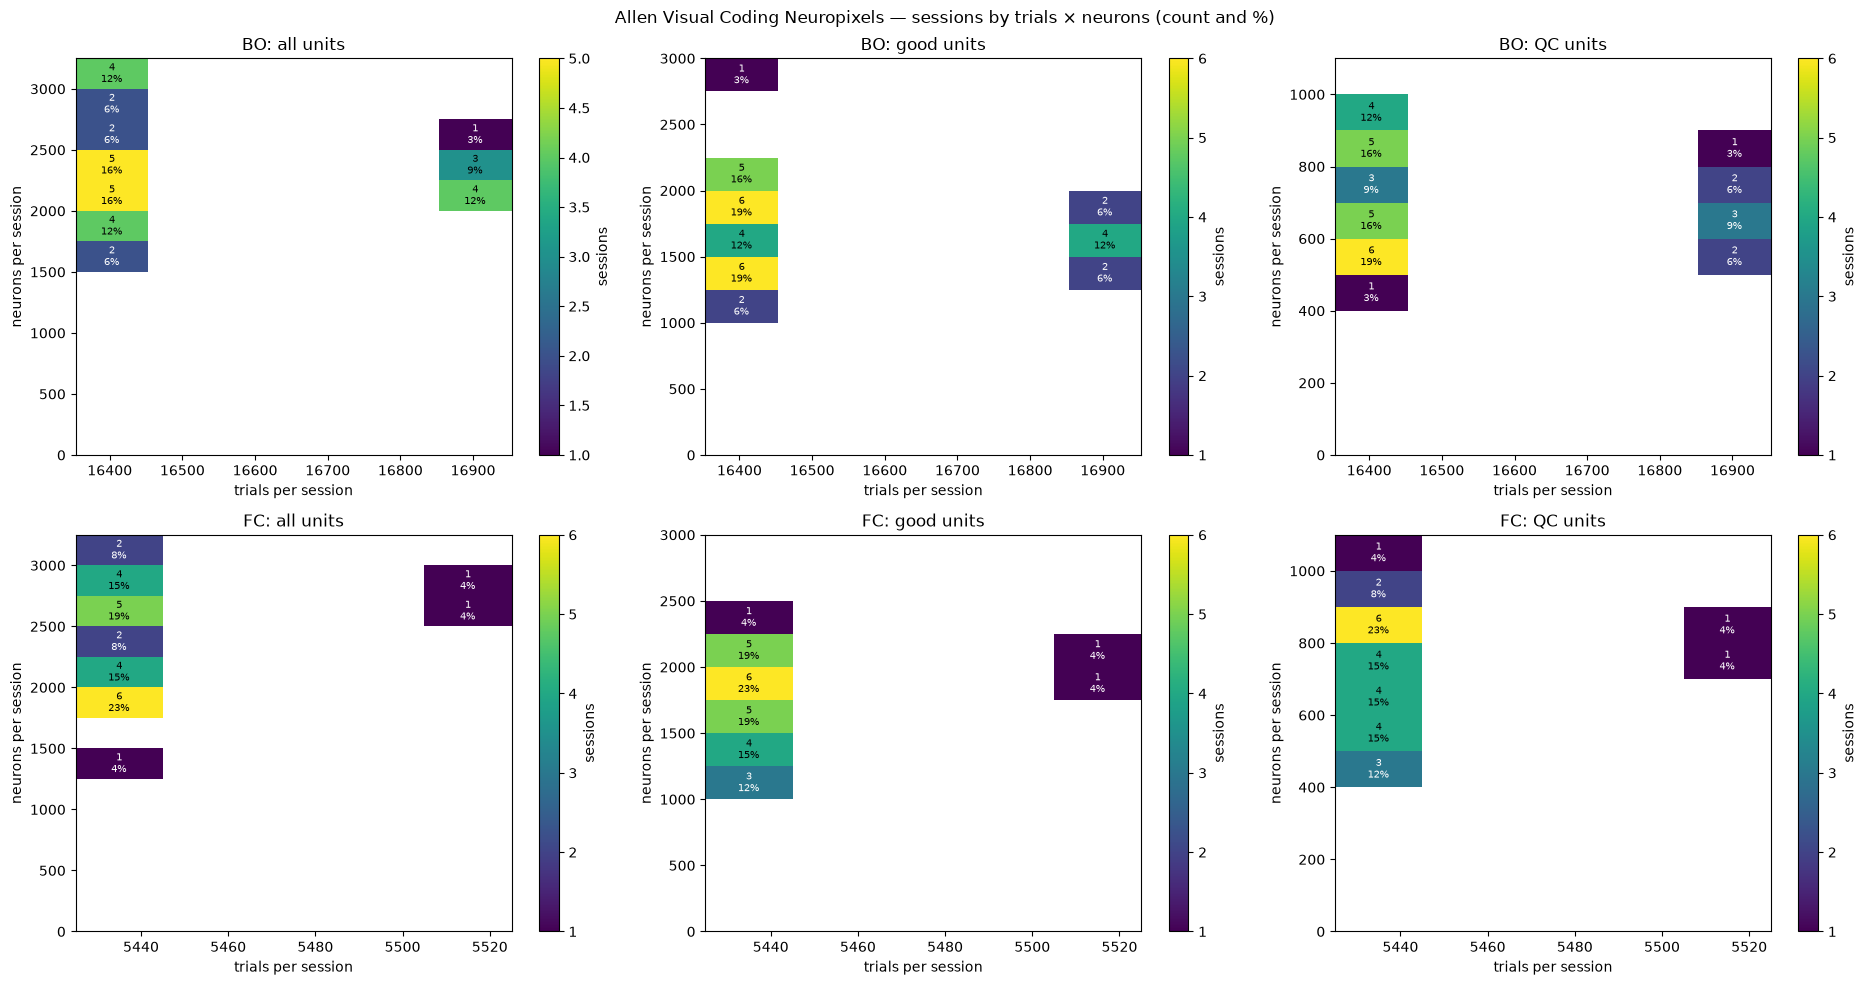

session_type brain_observatory_1.1             functional_connectivity      
trials                       16405 16945 16403                   5435  5510 
sessions                        20     8     4                      24     2

In [10]:
def heatmap(ax, x, y, xbins, ybins, title):
    H, xe, ye = np.histogram2d(x, y, [xbins, ybins])
    im = ax.pcolormesh(xe, ye, np.ma.masked_equal(H.T, 0), cmap="viridis", shading="flat")
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            if H[i, j]:
                ax.text((xe[i] + xe[i + 1]) / 2, (ye[j] + ye[j + 1]) / 2,
                        f"{H[i, j]:.0f}\n{H[i, j] / len(x) * 100:.0f}%", ha="center", va="center",
                        fontsize=7, color="w" if H[i, j] < 0.6 * H.max() else "k")
    ax.set(title=title, xlabel="trials per session", ylabel="neurons per session")
    plt.colorbar(im, ax=ax, label="sessions")


fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for row, t in enumerate((BO, FC)):
    s = sessions[sessions.session_type == t]
    lo, hi = s.trials.min(), s.trials.max()
    step = max(10, int(np.ceil((hi - lo + 1) / 6 / 10) * 10))
    xbins = np.arange(lo - step / 2, hi + step, step)
    heatmap(axes[row, 0], s.trials, s.units, xbins, np.arange(0, 3401, 250), f"{SHORT[t]}: all units")
    heatmap(axes[row, 1], s.trials, s.good_units, xbins, np.arange(0, 3001, 250), f"{SHORT[t]}: good units")
    heatmap(axes[row, 2], s.trials, s.qc_units, xbins, np.arange(0, 1101, 100), f"{SHORT[t]}: QC units")
fig.suptitle("Allen Visual Coding Neuropixels — sessions by trials × neurons (count and %)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_trials_x_neurons.png", dpi=150)
plt.show()
display(sessions.groupby("session_type").trials.value_counts().rename("sessions").to_frame().T)

### Brain regions

Units per structure (CCF acronym of each unit's peak channel), top 30 by unit count. `grey` = in the brain
but not assigned to a structure; blank = the unit's peak channel has no structure label (a few units on many probes, mostly near the top of
the shank; no probe is entirely blank).

The probes are aimed at the visual system, so most units are in visual cortex, the hippocampus below it,
and the thalamus below that:

| Group | Acronyms in the figure |
|---|---|
| Visual cortex | VISp primary visual; VISl lateral, VISli laterointermediate, VISal anterolateral, VISrl rostrolateral, VISam anteromedial, VISpm posteromedial, VISmma mediomedial anterior (higher visual areas); VIS = visual cortex, area not resolved |
| Hippocampus | CA1, CA3, DG dentate gyrus, SUB subiculum, ProS prosubiculum |
| Visual thalamus | LGd dorsal lateral geniculate (retina → cortex relay), LGv ventral lateral geniculate, LP lateral posterior (mouse pulvinar), POL posterior limiting nucleus |
| Other thalamus | TH thalamus (unresolved), VPM ventral posteromedial (whiskers), PO posterior complex, MGv / MGd medial geniculate (auditory), SGN suprageniculate, Eth ethmoid |
| Midbrain | APN anterior pretectal nucleus, NOT nucleus of the optic tract, MB midbrain (unresolved) |

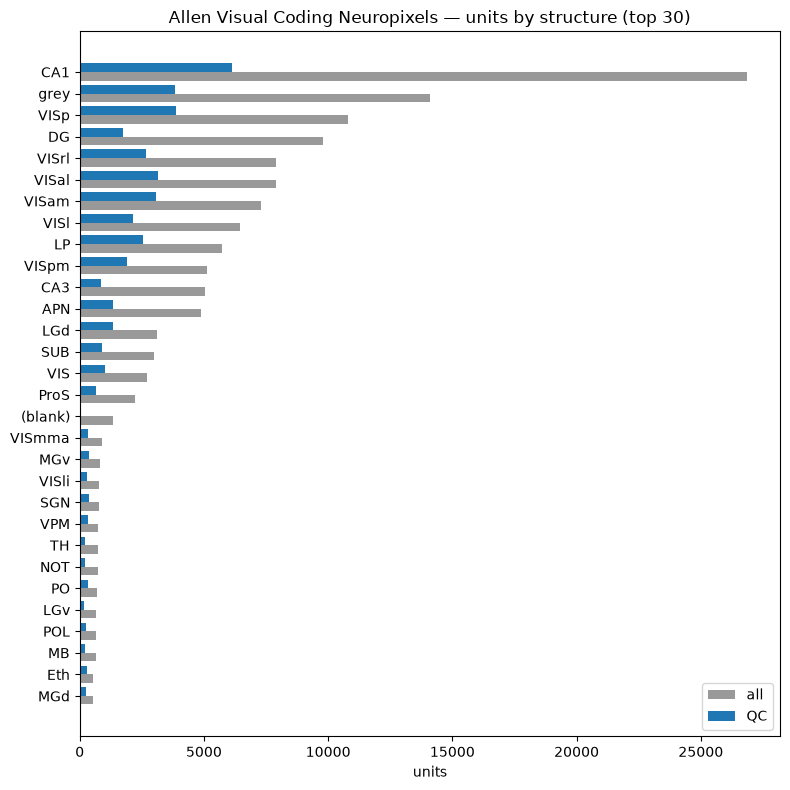

61 structures; visual cortex (VIS*) 50,211 units (18,534 QC)


In [11]:
region = units.region.replace("", "(blank)")
reg = pd.DataFrame({"all": region.value_counts(), "QC": region[units.qc].value_counts()}).fillna(0).astype(int)
reg = reg.sort_values("all").tail(30)
fig, ax = plt.subplots(figsize=(8, 8))
y = np.arange(len(reg))
ax.barh(y - 0.2, reg["all"], height=0.4, color="0.6", label="all")
ax.barh(y + 0.2, reg["QC"], height=0.4, color="C0", label="QC")
ax.set(yticks=y, yticklabels=reg.index, xlabel="units",
       title="Allen Visual Coding Neuropixels — units by structure (top 30)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_regions.png", dpi=150)
plt.show()
visual = units.region.str.startswith("VIS")
print(f"{units.region.nunique()} structures; visual cortex (VIS*) {visual.sum():,} units ({visual[units.qc].sum():,} QC)")

### Raster

An example BO session near the middle of the unit counts (739448407, at the BO median of good units), 30 s starting 5 s before its first flash. Rows = units, grouped by
probe and sorted by depth (tip at the bottom). Black = QC, gray = other good units; noise units are not drawn.

- **Shaded bands** — 250 ms full-field flashes, one every 2 s: yellow = screen turns white, purple = screen
  turns black. Before the first flash (0–5 s) the screen is gray. Each flash is one trial.
- **Blue horizontal lines** — boundaries between probes (probe names on the right). Each probe is a separate
  shank in a different part of the visual system, recorded at the same time.

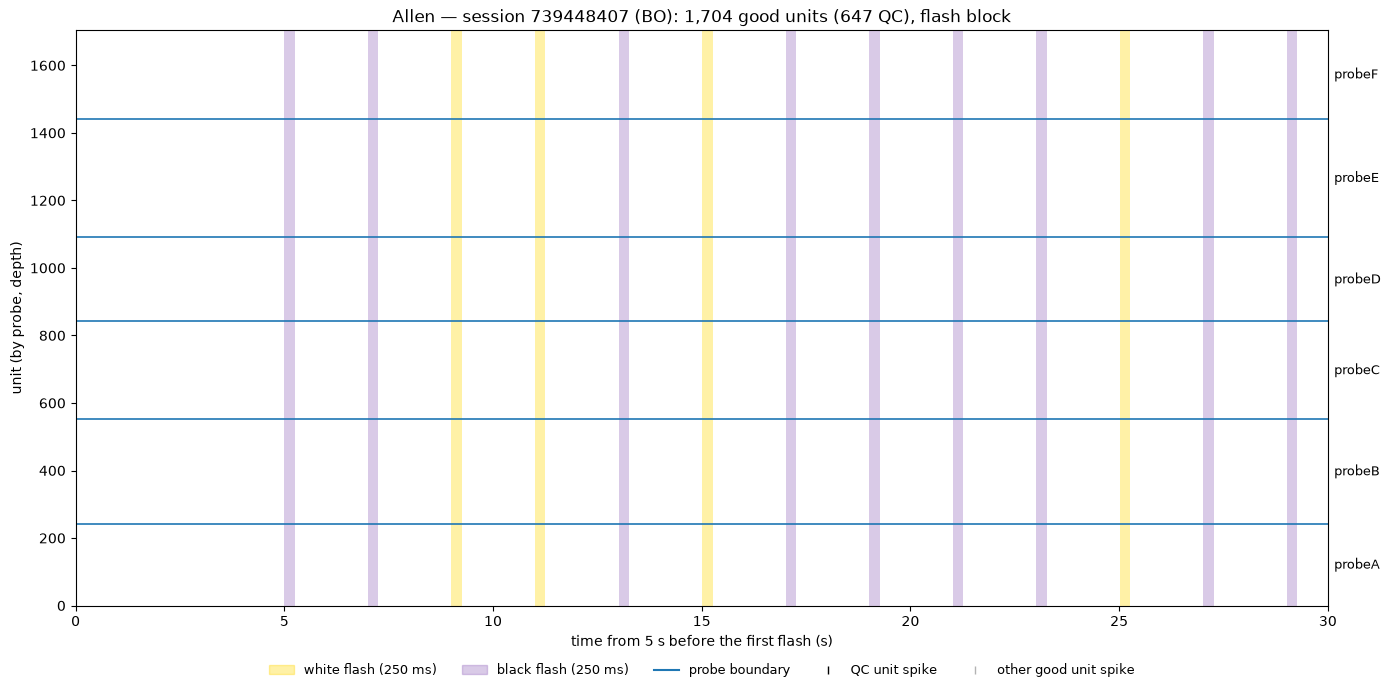

In [12]:
r = np.load(TABLES / "raster.npz")
sid = int(r["session_id"])
s = sessions.set_index("session_id").loc[sid]
u = units[units.session_id == sid].reset_index(drop=True)
assert (u.unit_id.to_numpy() == r["unit_id"]).all()
u["nwb_row"] = np.arange(len(u))
shown = u[u.good].sort_values(["probe", "depth_um"]).reset_index(drop=True)
shown["row"] = np.arange(len(shown))
spk = pd.DataFrame({"nwb_row": r["unit_row"], "t": r["times"]}).merge(
    shown[["nwb_row", "row", "qc"]], on="nwb_row", how="inner")

fig, ax = plt.subplots(figsize=(14, 7))
for on, color in zip(r["flash_on"], r["flash_color"]):
    ax.axvspan(on, on + 0.25, color="gold" if color > 0 else "C4", alpha=0.35, lw=0)
for qc, color in [(False, "0.7"), (True, "k")]:
    d = spk[spk.qc == qc]
    ax.scatter(d.t, d.row, s=0.3, color=color, marker="|", linewidths=0.4, rasterized=True)
for p, grp in shown.groupby("probe"):
    if grp.row.max() < len(shown) - 1:
        ax.axhline(grp.row.max() + 0.5, color="C0", lw=1.2)
    ax.text(float(r["window_s"]) * 1.005, grp.row.mean(), p, va="center", fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="gold", alpha=0.35, label="white flash (250 ms)"),
    plt.Rectangle((0, 0), 1, 1, color="C4", alpha=0.35, label="black flash (250 ms)"),
    plt.Line2D([], [], color="C0", lw=1.5, label="probe boundary"),
    plt.Line2D([], [], color="k", marker="|", ls="", label="QC unit spike"),
    plt.Line2D([], [], color="0.7", marker="|", ls="", label="other good unit spike"),
], loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=9, frameon=False)
ax.set(xlim=(0, float(r["window_s"])), ylim=(-0.5, len(shown) - 0.5),
       xlabel="time from 5 s before the first flash (s)", ylabel="unit (by probe, depth)",
       title=f"Allen — session {sid} ({SHORT[s.session_type]}): {len(shown):,} good units "
             f"({int(shown.qc.sum())} QC), flash block")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_raster.png", dpi=150)
plt.show()

## 4. Which sessions the draft uses

Draft Table 8 has four Allen splits: BO drifting one TF (959 neurons, 120 trials), Flash BO top (959, 150),
Flash FC second (930, 150) and Flash FC top (1,005, 150). 120 = 8 directions × 15 repeats at one temporal
frequency, and 150 = one session's flash block.

The run that produced them does not record session IDs. **top** / **second** match ranking sessions by QC
unit count: the top sessions are BO 757216464 (984 QC units), FC 794812542 (1,036) and FC 771160300 (971).
Dropping units that are nearly silent during the flash block (≥ 17 spikes in the 150 × 2 s flash trials,
about 0.06 Hz) lands within 5 units of all three draft counts. The exact rule is not recoverable, but
the sessions are clear.

In [13]:
w = pd.read_parquet(TABLES / "draft_window_counts.parquet")
draft = {"Flash BO top": (757216464, 959), "Flash FC top": (794812542, 1005), "Flash FC second": (771160300, 930)}
display(pd.DataFrame([
    {"split": k, "session_id": sid, "draft neurons": n,
     "QC units": int((w.session_id == sid).sum()),
     "QC & ≥ 17 flash spikes": int(((w.session_id == sid) & (w.flash_spikes >= 17)).sum()),
     "session rank by QC (within type)": int(sessions[sessions.session_type == session_type[sid]]
                                             .qc_units.rank(ascending=False, method="min")
                                             [sessions.session_id == sid].iloc[0])}
    for k, (sid, n) in draft.items()
]))

,split,session_id,draft neurons,QC units,QC & ≥ 17 flash spikes,session rank by QC (within type)
0,Flash BO top,757216464,959,984,959,1
1,Flash FC top,794812542,1005,1036,1010,1
2,Flash FC second,771160300,930,971,931,2


## Spreadsheet

- Same columns as the NLB / FALCON / IBL CSVs, one row per session type. CHANNELS = `N/A` (sorted units).
- Length: 1 decimal minute. RAW / BENCHMARK: 3 decimal GB.
- This cell writes `tutorials/allen_datasets.csv`.

In [14]:
templates = bucket[bucket.kind == "templates"]
template_gb = {
    BO: templates.bytes.sum() / GB,  # natural scenes + movies one and three
    FC: templates.bytes[templates.key.str.endswith("natural_movie_1.h5")].sum() / GB,
}
store = storage.set_index("session_id")
store["type"] = session_type
bytes_per_spike = store.spike_times.sum() / sessions.spikes.sum()
qc_spikes = units[units.qc].groupby("session_id").spike_count.sum()
store["qc_spike_bytes"] = qc_spikes.reindex(store.index).fillna(0) * bytes_per_spike
store["benchmark"] = store.qc_spike_bytes + store.other
fr_all, fr_qc = units.firing_rate, units.firing_rate[units.qc]

rows = []
for t, name in [(BO, "Allen VCN Brain Observatory"), (FC, "Allen VCN Functional Connectivity")]:
    s, u, b = sessions[sessions.session_type == t], units[units.type == t], bucket[bucket.type == t]
    st = trial_stims[trial_stims.type == t].stimulus.value_counts().reindex(STIM_ORDER).dropna().astype(int)
    stim_text = ", ".join(f"{k} {v:,}" for k, v in st.items())
    fr_t, fr_tq = u.firing_rate, u.firing_rate[u.qc]
    raw_gb = b.bytes.sum() / GB
    bench_gb = (store.benchmark[store.type == t].sum() + b.bytes[b.kind == "session_metrics"].sum()) / GB \
        + template_gb[t]
    draft_note = ("Draft Table 8 (inferred; the draft's unit rule and session IDs are not recorded): Flash BO top is most likely session 757216464, the BO session with the most QC units; BO drifting one TF has the same 959 neurons, so presumably the same session."
                  if t == BO else
                  "Draft Table 8 (inferred; the draft's unit rule and session IDs are not recorded): Flash FC top and second are most likely sessions 794812542 and 771160300, the FC sessions with the most QC units.")
    notes = (
        f"Allen Brain Observatory Visual Coding Neuropixels, {SHORT[t]} session type: {len(s)} sessions, one per mouse "
        f"({s.genotype.eq('wt/wt').sum()} wild type, {(~s.genotype.eq('wt/wt')).sum()} Cre;Ai32 opto-tagging lines); "
        f"passive viewing, head-fixed on a running wheel; {int(s.probes.sum())} Neuropixels 1.0 probes "
        f"({int(s.probes.min())}–{int(s.probes.max())} per session); CHANNELS N/A because units are sorted (Kilosort2). "
        f"NEURONS = AllenSDK default QC units (quality good & ISI violations < 0.5 & amplitude cutoff < 0.1 & "
        f"presence ratio > 0.9); all NWB units {len(u):,} (median "
        f"{half_up(s.units.median())}/session), good (not noise) {int(u.good.sum()):,} (median {half_up(s.good_units.median())}/session). "
        f"TRIALS = stimulus presentations, movies counted per repeat, spontaneous excluded: {stim_text}. "
        f"LENGTH = first-to-last spike per session, summed ({s.recording_s.sum() / 3600:,.1f} h). "
        f"RAW = bucket files for these sessions: session NWBs {b.bytes[b.kind == 'session_nwb'].sum() / GB:.1f} GB + "
        f"LFP {b.bytes[b.kind == 'lfp'].sum() / GB:.1f} GB + unit metric CSVs {b.bytes[b.kind == 'session_metrics'].sum() / GB:.3f} GB "
        f"(no raw 30 kHz voltage is public). "
        f"BENCHMARK = QC-unit spike times ({store.qc_spike_bytes[store.type == t].sum() / GB:.1f} GB) + NWB stimulus "
        f"tables, unit metadata, running and eye tracking (eye tracking in {int(s.has_eye_tracking.sum())} of {len(s)} sessions; "
        f"{store.other[store.type == t].sum() / GB:.1f} GB) + unit metric CSVs and stimulus templates "
        f"({(b.bytes[b.kind == 'session_metrics'].sum() / GB + template_gb[t]):.2f} GB); per-spike amplitudes and mean waveforms dropped; "
        f"all-unit spike times would be {store.spike_times[store.type == t].sum() / GB:.1f} GB. " + draft_note
    )
    rows.append({
        "DATASET": name,
        "ANIMAL": "Mouse",
        "SUBJECTS": s.specimen_id.nunique(),
        "TRIALS": int(s.trials.sum()),
        "TOTAL CHANNELS": "N/A",
        "MEDIAN CHANNELS": "N/A",
        "TOTAL NEURONS": int(s.qc_units.sum()),
        "MEDIAN NEURONS": half_up(s.qc_units.median()),
        "RECORDING LENGTH (min)": round(s.recording_s.sum() / 60, 1),
        "RAW DATASET SIZE (GB)": round(raw_gb, 3),
        "BENCHMARK DATASET SIZE (GB)": round(bench_gb, 3),
        "NOTES": notes,
        "BASIC STATS": (f"QC-unit firing rate: mean {fr_tq.mean():.2f}, median {fr_tq.median():.2f} spikes/s "
                        f"(all units: mean {fr_t.mean():.2f}, median {fr_t.median():.2f})"),
    })
inventory = pd.DataFrame(rows)
display(inventory.drop(columns="NOTES").T)
for n in inventory.NOTES:
    print(n, "\n")
csv_path = REPO / "tutorials" / "allen_datasets.csv"
inventory.to_csv(csv_path, index=False)
print("wrote", csv_path)

,0,1
DATASET,Allen VCN Brain Observatory,Allen VCN Functional Connectivity
ANIMAL,Mouse,Mouse
SUBJECTS,32,26
TRIALS,529272,141460
TOTAL CHANNELS,N/A,N/A
MEDIAN CHANNELS,N/A,N/A
TOTAL NEURONS,22638,18914
MEDIAN NEURONS,682,736
RECORDING LENGTH (min),5242.0,4284.1
RAW DATASET SIZE (GB),477.616,374.988


Allen Brain Observatory Visual Coding Neuropixels, BO session type: 32 sessions, one per mouse (16 wild type, 16 Cre;Ai32 opto-tagging lines); passive viewing, head-fixed on a running wheel; 183 Neuropixels 1.0 probes (4–6 per session); CHANNELS N/A because units are sorted (Kilosort2). NEURONS = AllenSDK default QC units (quality good & ISI violations < 0.5 & amplitude cutoff < 0.1 & presence ratio > 0.9); all NWB units 74,658 (median 2292/session), good (not noise) 54,476 (median 1684/session). TRIALS = stimulus presentations, movies counted per repeat, spontaneous excluded: flashes 4,800, drifting_gratings 20,152, drifting_gratings_contrast 4,320, static_gratings 192,000, gabors 116,640, natural_scenes 190,400, natural_movie_one 640, natural_movie_three 320. LENGTH = first-to-last spike per session, summed (87.4 h). RAW = bucket files for these sessions: session NWBs 80.5 GB + LFP 397.1 GB + unit metric CSVs 0.053 GB (no raw 30 kHz voltage is public). BENCHMARK = QC-unit spike times